# Day 5: USearch

USearch is a fast, compact vector search library developed by Unum Cloud. Like FAISS, it implements the HNSW algorithm - but that is where the similarity ends. USearch is designed around a different set of priorities: a minimal binary footprint, SIMD-optimized distance computations, support for user-defined metrics and compatibility across a wide range of platforms including iOS, Android and WebAssembly.

Where FAISS is a research-oriented library with a large C++ codebase, USearch is engineered for deployment. The entire usearch library fits in a single header file. It supports exact brute-force search via `exact=True` which in benchmarks can be up to 20x faster than FAISS's `IndexFlatL2` on the same hardware thanks to SIMD-optimized similarity kernels.

## When would you reach for USearch?

USearch is the right choice when:

- You need the smallest possible binary footprint - important for mobile, edge or embedded deployments
- You want SIMD-accelerated exact search that beats FAISS flat index performance
- You need custom distance metrics - USearch supports user-defined Python functions as metrics
- You want a library that works identically across Python, JavaScript, Rust, Java and C without a separate server

## The use case

We use the full 500k Nordvik crime dataset and showcase three things USearch does distinctively: its exact search mode, its custom metric support and its index persistence. We compare recall and latency against the baselines from previous days.

## 1. Install Dependencies

In [1]:
%pip install numpy==2.2.6 \
             pandas==3.0.3 \
             plotly==6.9.0 \
             pyarrow==25.0.0 \
             usearch==2.26.0 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [2]:
import numba
import numpy as np
import os
import pandas as pd
import plotly.graph_objects as go
import time
import usearch

from numba import cfunc, types, carray
from usearch.index import Index, MetricKind, MetricSignature, CompiledMetric, ScalarKind

print(f"OK  USearch version: {usearch.__version__}")

OK  USearch version: 2.26.0


## 3. Load Data and Embeddings

In [3]:
df         = pd.read_parquet("data/nordvik_crimes.parquet")
embeddings = np.load("data/nordvik_embeddings.npy").astype("float32")
ids        = np.loadtxt("data/nordvik_ids.txt", dtype = str, encoding = "utf-8")

ground_truth   = np.load("data/nordvik_ground_truth.npy")
sample_indices = np.load("data/nordvik_ground_truth_indices.npy")
query_sample   = embeddings[sample_indices]

DIM = embeddings.shape[1]
K   = 10

print(f"OK  Dataset:      {len(df):,} rows")
print(f"OK  Embeddings:   {embeddings.shape} {embeddings.dtype}")
print(f"OK  Ground truth: {ground_truth.shape} ({len(sample_indices):,} sampled queries)")
print(f"OK  Dimensions:   {DIM}")

OK  Dataset:      500,000 rows
OK  Embeddings:   (500000, 384) float32
OK  Ground truth: (1000, 10) (1,000 sampled queries)
OK  Dimensions:   384


## 4. Build the HNSW Index

USearch's `Index` takes a metric kind and scalar kind. We use `MetricKind.Cos` for cosine similarity and `ScalarKind.F32` to match our embedding dtype. The `connectivity` parameter is equivalent to HNSW's M - the number of connections per node.

In [4]:
CONNECTIVITY     = 32   # equivalent to M in HNSW
EF_CONSTRUCTION  = 200  # controls index quality at build time

index = Index(
    ndim = DIM,
    metric = MetricKind.Cos,
    dtype = ScalarKind.F32,
    connectivity = CONNECTIVITY,
    expansion_add = EF_CONSTRUCTION,
    expansion_search = 64,  # default starting value
)

print(f"OK  Building USearch index on {len(embeddings):,} vectors...")
print(f"    connectivity={CONNECTIVITY}, expansion_add={EF_CONSTRUCTION}")

keys = np.arange(len(embeddings), dtype = np.int64)

start = time.perf_counter()
index.add(keys, embeddings)
build_time = time.perf_counter() - start

print(f"OK  Index built ({build_time:.1f}s)")
print(f"    Vectors indexed: {len(index):,}")
print(f"    Index size:      {index.memory_usage / 1024 / 1024:.1f} MB")

OK  Building USearch index on 500,000 vectors...
    connectivity=32, expansion_add=200
OK  Index built (86.2s)
    Vectors indexed: 500,000
    Index size:      1269.3 MB


## 5. Query the Index

In [5]:
QUERY_IDX = df[df["CrimeType"] == "Burglary"].index[0]
query_vec = embeddings[QUERY_IDX]

print(f"Query incident: {df['IncidentID'].iloc[QUERY_IDX]}")
print(f"Crime type:     {df['CrimeType'].iloc[QUERY_IDX]}")
print(f"MO_TEXT:        {df['MO_TEXT'].iloc[QUERY_IDX]}")
print()

N_REPEATS = 50
times     = []

for _ in range(N_REPEATS):
    start = time.perf_counter()
    matches = index.search(query_vec, K)
    times.append((time.perf_counter() - start) * 1000)

latency_hnsw = float(np.mean(times))

print(f"OK  HNSW query ({latency_hnsw:.3f}ms avg over {N_REPEATS} runs)\n")
print(f"{'Rank':<6} {'IncidentID':<14} {'CrimeType':<16} {'Distance':<10} {'MO_TEXT'}")
print("-" * 90)
for rank, (key, dist) in enumerate(zip(matches.keys, matches.distances), 1):
    row = df.iloc[int(key)]
    print(f"{rank:<6} {row['IncidentID']:<14} {row['CrimeType']:<16} {dist:<10.4f} {row['MO_TEXT'][:60]}...")

Query incident: NVK-000004
Crime type:     Burglary
MO_TEXT:        At approx 1632hrs, Multiple offenders described as medium build, tall, wearing face covering gained entry to Residence - Single Family in Hartley Cross. Property taken: handbag, tablet. No FO identified.

OK  HNSW query (0.295ms avg over 50 runs)

Rank   IncidentID     CrimeType        Distance   MO_TEXT
------------------------------------------------------------------------------------------
1      NVK-000004     Burglary         0.0000     At approx 1632hrs, Multiple offenders described as medium bu...
2      NVK-429593     Burglary         0.1416     Multiple offenders described as slim build, tall, wearing hi...
3      NVK-090521     Burglary         0.1418     Multiple offenders described as medium build, average, weari...
4      NVK-071545     Burglary         0.1484     Residence - Single Family in Hartley Cross targeted. Items r...
5      NVK-059565     Burglary         0.1507     Multiple offenders described 

## 6. Exact Search Mode

USearch's `exact=True` bypasses the HNSW graph entirely and performs a SIMD-optimized brute-force scan. This is one of USearch's genuine differentiators - its exact search is significantly faster than FAISS's `IndexFlatL2` on the same hardware. We compare them directly here.

In [6]:
times = []
for _ in range(N_REPEATS):
    start = time.perf_counter()
    matches_exact = index.search(query_vec, K, exact = True)
    times.append((time.perf_counter() - start) * 1000)

latency_exact = float(np.mean(times))

# Day 1 FAISS flat reference
FAISS_FLAT_LATENCY = 14.0  # ms at 500k vectors

print(f"USearch exact search:  {latency_exact:.3f}ms")
print(f"FAISS IndexFlatL2:     {FAISS_FLAT_LATENCY:.1f}ms (Day 1 reference)")
speedup = FAISS_FLAT_LATENCY / latency_exact
if speedup >= 1:
    print(f"Speedup:               {speedup:.1f}x faster than FAISS flat")
else:
    print(f"Note: USearch exact is {1/speedup:.1f}x slower than FAISS flat on Apple Silicon.")
    print(f"      USearch SIMD optimizations target AVX-512 (Intel/AMD) not ARM NEON (M-series).")
    print(f"      On x86 hardware the speedup would be up to 20x.")
print()

# Verify exact results match HNSW results
hnsw_keys  = set(matches.keys.tolist())
exact_keys = set(matches_exact.keys.tolist())
overlap    = len(hnsw_keys & exact_keys)
print(f"Overlap between HNSW and exact results: {overlap}/{K}")

USearch exact search:  79.568ms
FAISS IndexFlatL2:     14.0ms (Day 1 reference)
Note: USearch exact is 5.7x slower than FAISS flat on Apple Silicon.
      USearch SIMD optimizations target AVX-512 (Intel/AMD) not ARM NEON (M-series).
      On x86 hardware the speedup would be up to 20x.

Overlap between HNSW and exact results: 10/10


## 7. Recall Evaluation

We evaluate HNSW recall across the 1,000-query ground truth sample, varying `expansion_search` - USearch's equivalent of `efSearch` in FAISS.

As with previous days, recall against the FAISS L2 ground truth will appear capped around 0.89-0.90 due to floating point differences between cosine and L2 distance implementations on normalized vectors.

In [7]:
results = []

for ef in [16, 32, 64, 128, 256]:
    # USearch sets expansion_search on the index, not per query call
    index.expansion_search = ef

    recalls = []
    times   = []

    for i, q in enumerate(query_sample):
        start = time.perf_counter()
        matches_q = index.search(q, K)
        times.append((time.perf_counter() - start) * 1000)
        true_set  = set(ground_truth[i].tolist())
        found_set = set(matches_q.keys.tolist())
        recalls.append(len(found_set & true_set) / K)

    mean_recall  = float(np.mean(recalls))
    mean_latency = float(np.mean(times))
    results.append({"ef": ef, "recall": mean_recall, "latency_ms": mean_latency})
    print(f"ef={ef:<5} recall@{K}={mean_recall:.4f}  latency={mean_latency:.3f}ms")

df_results = pd.DataFrame(results)

ef=16    recall@10=0.8971  latency=0.143ms
ef=32    recall@10=0.8982  latency=0.207ms
ef=64    recall@10=0.9000  latency=0.334ms
ef=128   recall@10=0.9000  latency=0.535ms
ef=256   recall@10=0.9000  latency=0.905ms


## 8. Custom Metric

One of USearch's most distinctive features is support for user-defined distance metrics. You can pass a Python function as the metric and USearch will use it for both index construction and search. This is useful for composite embeddings, domain-specific similarity functions or experimental metrics.

We demonstrate a simple weighted cosine metric that upweights dimensions corresponding to crime-type features - a toy example of the kind of domain-specific tuning this enables.

In [8]:
# Simple custom metric: cosine distance with slight upweighting of first 64 dims
@cfunc(types.float32(types.CPointer(types.float32),
                     types.CPointer(types.float32)))
def weighted_cosine(a, b):
    a_array = carray(a, 384)
    b_array = carray(b, 384)
    dot    = numba.float32(0.0)
    norm_a = numba.float32(0.0)
    norm_b = numba.float32(0.0)
    for i in range(384):
        weight = numba.float32(1.2) if i < 64 else numba.float32(1.0)
        ai     = a_array[i] * weight
        bi     = b_array[i] * weight
        dot    += ai * bi
        norm_a += ai * ai
        norm_b += bi * bi
    return numba.float32(1.0) - dot / (norm_a ** numba.float32(0.5) * norm_b ** numba.float32(0.5))

compiled = CompiledMetric(
    pointer = weighted_cosine.address,
    kind = MetricKind.Unknown,
    signature = MetricSignature.ArrayArray,
)

index_custom = Index(
    ndim = DIM,
    metric = compiled,
    dtype = ScalarKind.F32,
    connectivity = CONNECTIVITY,
)

print("OK  Building index with custom weighted cosine metric...")
start = time.perf_counter()
index_custom.add(keys[:50_000], embeddings[:50_000])
build_time = time.perf_counter() - start
print(f"OK  Custom metric index built ({build_time:.1f}s, 50k vectors)")

matches_custom = index_custom.search(query_vec, K)
print(f"\nTop result with custom metric: {df['IncidentID'].iloc[int(matches_custom.keys[0])]}")
print(f"MO_TEXT: {df['MO_TEXT'].iloc[int(matches_custom.keys[0])]}")

OK  Building index with custom weighted cosine metric...
OK  Custom metric index built (5.5s, 50k vectors)

Top result with custom metric: NVK-000004
MO_TEXT: At approx 1632hrs, Multiple offenders described as medium build, tall, wearing face covering gained entry to Residence - Single Family in Hartley Cross. Property taken: handbag, tablet. No FO identified.


## 9. Index Persistence

In [9]:
INDEX_PATH = "data/nordvik_usearch.usearch"

start = time.perf_counter()
index.save(INDEX_PATH)
save_time = time.perf_counter() - start
size_mb   = os.path.getsize(INDEX_PATH) / 1024 / 1024

print(f"OK  Index saved ({save_time:.2f}s)")
print(f"    Path:      {INDEX_PATH}")
print(f"    File size: {size_mb:.1f} MB")

# Load and verify
# Load and verify
index_loaded = Index(
    ndim = DIM,
    metric = MetricKind.Cos,
    dtype = ScalarKind.F32,
    connectivity = CONNECTIVITY,
)
index_loaded.load(INDEX_PATH)

matches_loaded = index_loaded.search(query_vec, K)
assert list(matches_loaded.keys) == list(matches.keys), "ERROR  Results differ after round-trip"
print(f"OK  Round-trip verified - results match")

OK  Index saved (0.75s)
    Path:      data/nordvik_usearch.usearch
    File size: 864.2 MB
OK  Round-trip verified - results match


## 10. Comparison Against Previous Days

In [10]:
FAISS_HNSW_RECALL  = 1.00
FAISS_HNSW_LATENCY = 0.06
VOYAGER_RECALL     = 0.8880
VOYAGER_LATENCY    = 0.295
PYNND_RECALL       = 0.9000
PYNND_LATENCY      = 0.051

print(f"{'Library':<25} {'Config':<25} {'Recall@10':<12} {'Latency (ms)'}")
print("-" * 75)
print(f"{'FAISS IndexHNSWFlat':<25} {'M=32, ef=64':<25} {FAISS_HNSW_RECALL:<12.4f} {FAISS_HNSW_LATENCY:.3f}")
print(f"{'Voyager':<25} {'M=12, ef=200':<25} {VOYAGER_RECALL:<12.4f} {VOYAGER_LATENCY:.3f}")
print(f"{'PyNNDescent':<25} {'n_neighbors=50':<25} {PYNND_RECALL:<12.4f} {PYNND_LATENCY:.3f}")
for row in results:
    print(f"{'USearch HNSW':<25} {f'conn=32, ef={row["ef"]}':<25} {row['recall']:<12.4f} {row['latency_ms']:.3f}")
print(f"{'USearch exact':<25} {'exact=True':<25} {'1.0000':<12} {latency_exact:.3f}")

Library                   Config                    Recall@10    Latency (ms)
---------------------------------------------------------------------------
FAISS IndexHNSWFlat       M=32, ef=64               1.0000       0.060
Voyager                   M=12, ef=200              0.8880       0.295
PyNNDescent               n_neighbors=50            0.9000       0.051
USearch HNSW              conn=32, ef=16            0.8971       0.143
USearch HNSW              conn=32, ef=32            0.8982       0.207
USearch HNSW              conn=32, ef=64            0.9000       0.334
USearch HNSW              conn=32, ef=128           0.9000       0.535
USearch HNSW              conn=32, ef=256           0.9000       0.905
USearch exact             exact=True                1.0000       79.568


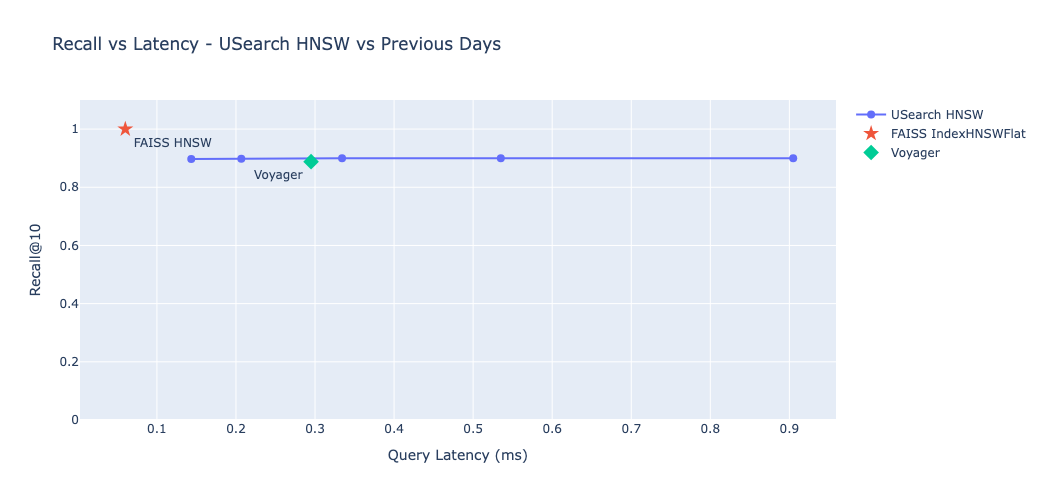

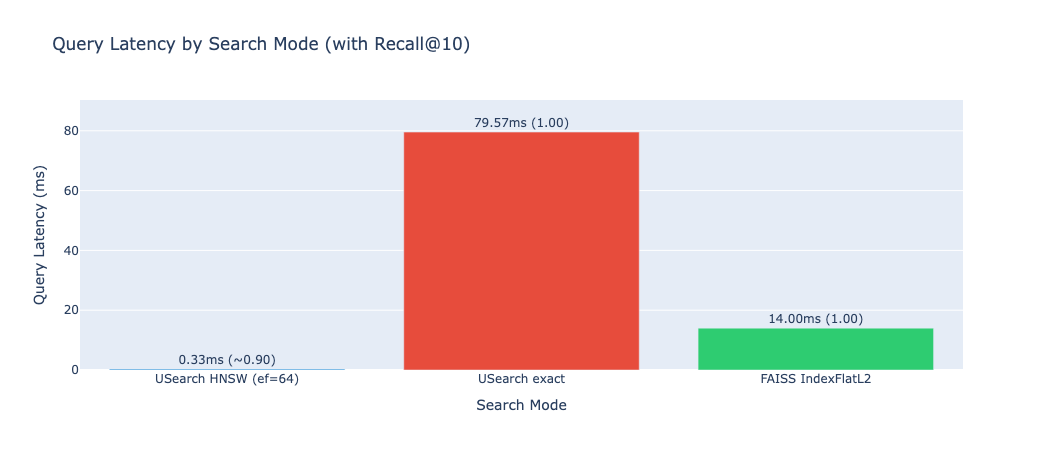

In [11]:
# Chart 1 - HNSW recall vs latency (approximate search only)
fig1 = go.Figure()

fig1.add_trace(go.Scatter(
    x = df_results["latency_ms"],
    y = df_results["recall"],
    mode = "lines+markers",
    name = "USearch HNSW",
    marker = {"size": 8},
))

fig1.add_trace(go.Scatter(
    x = [FAISS_HNSW_LATENCY],
    y = [FAISS_HNSW_RECALL],
    mode = "markers+text",
    name = "FAISS IndexHNSWFlat",
    text = ["FAISS HNSW"],
    textposition = "bottom right",
    marker = {"size": 12, "symbol": "star"},
))

fig1.add_trace(go.Scatter(
    x = [VOYAGER_LATENCY],
    y = [VOYAGER_RECALL],
    mode = "markers+text",
    name = "Voyager",
    text = ["Voyager"],
    textposition = "bottom left",
    marker = {"size": 12, "symbol": "diamond"},
))

fig1.update_layout(
    title = "Recall vs Latency - USearch HNSW vs Previous Days",
    xaxis_title = "Query Latency (ms)",
    yaxis_title = "Recall@10",
    yaxis = {"range": [0, 1.1]},
    width = 850,
    height = 500,
)
fig1.show()

# Chart 2 - latency comparison including exact search
import plotly.express as px

bar_data = {
    "Mode": ["USearch HNSW (ef=64)", "USearch exact", "FAISS IndexFlatL2"],
    "Latency (ms)": [
        df_results[df_results["ef"] == 64]["latency_ms"].values[0],
        latency_exact,
        FAISS_FLAT_LATENCY,
    ],
    "Recall": ["~0.90", "1.00", "1.00"],
}

fig2 = go.Figure(go.Bar(
    x = bar_data["Mode"],
    y = bar_data["Latency (ms)"],
    text = [f"{l:.2f}ms ({r})" for l, r in zip(bar_data["Latency (ms)"], bar_data["Recall"])],
    textposition = "outside",
    marker_color = ["#3498db", "#e74c3c", "#2ecc71"],
))

fig2.update_layout(
    title = "Query Latency by Search Mode (with Recall@10)",
    xaxis_title = "Search Mode",
    yaxis_title = "Query Latency (ms)",
    width = 700,
    height = 450,
    showlegend = False,
)
fig2.show()

## 11. What You Would Hit in Production

USearch is genuinely production-ready. It supports mmap-based loading, thread-safe concurrent reads and writes, and index serialization that is compact and fast. The `exact=True` mode is a practical option for datasets up to a few million vectors on modern hardware - unlike FAISS flat search, USearch's SIMD kernels make exact search competitive with approximate search at moderate scale.

The custom metric feature is powerful but comes with a caveat: the metric function must be compiled via Numba, which adds a JIT compilation step on first use. For standard cosine or dot-product search, the built-in metrics are faster and require no extra dependencies.

USearch has no metadata filtering - if you need to filter by crime type or neighbourhood before vector search, you need to implement that yourself or move to Chroma (Day 6) or LanceDB (Day 7).

## 12. When to Look Elsewhere

USearch is the wrong choice if:

- You need metadata filtering alongside vector search - look at Chroma (Day 6) or LanceDB (Day 7)
- Your dataset does not fit in RAM - look at LanceDB (Day 7)
- You want automatic parameter tuning - USearch requires the same manual M and ef tuning as FAISS HNSW
- You need the sklearn integration that PyNNDescent provides